## ANDRIANTENAINA Jean Claude

In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Enter the password here


In [154]:
password = "3me7vdo_"

In [156]:
from npz_loader import load_encrypted_npz

data = load_encrypted_npz(password)

In [157]:
print("Decrypted data:", data)

Decrypted data: {'X_train': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 'y_train': array([1, 2, 1, ..., 2, 2, 1], dtype=uint8), 'X_test': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)}


# Now start working


## Preparate the data

In [162]:
data['y_train'].shape

(12700,)

In [163]:
y0_train = data['y_train'].reshape(data['y_train'].shape[0], 1)

In [166]:
y0_train.shape

(12700, 1)

In [167]:
y0_train

array([[1],
       [2],
       [1],
       ...,
       [2],
       [2],
       [1]], dtype=uint8)

### change the values in y_train =: y0_train : 1 => 0 and 2 => 1

In [171]:
y0_train = np.where(y0_train == 2, 1, 0)

In [172]:
y0_train

array([[0],
       [1],
       [0],
       ...,
       [1],
       [1],
       [0]])

### concanate X_train and y_train

In [176]:
new_data = np.concatenate((data['X_train'], y0_train), axis = 1)

In [177]:
new_data.shape

(12700, 785)

In [180]:
type(new_data)

numpy.ndarray

In [182]:
new_data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 0]])

### find if there are a NaN or duplicate element(row)

In [185]:
unique_data = np.unique(new_data, axis = 0)

In [186]:
unique_data.shape

(12700, 785)

In [187]:
# haven't NaN or repeted element, so new_data itself who use below

### add index in new_data who Ndarray's type

In [189]:
index = [f'{i}' for i in range(new_data.shape[0])]

In [190]:
df = pd.DataFrame(new_data, index=index)

In [191]:
df

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12695,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
12696,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12697,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
12698,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


### data simple view

In [193]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
count,12700.0,12700.0,12700.0,12700.0,12700.0,12700.0,12700.0,12700.0,12700.0,12700.0,...,12700.0,12700.0,12700.0,12700.0,12700.0,12700.0,12700.0,12700.0,12700.0,12700.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.469134
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.499066
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000


## Split the train and the test of the data

In [201]:
def train_test_split(df, target, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    train_index = np.random.choice(df.index, size=int(len(df) * (1 - test_size)), replace=False)
    test_index = np.setdiff1d(df.index, train_index)
    
    return df.loc[train_index, df.columns != target], df.loc[test_index, df.columns != target], df.loc[train_index, target], df.loc[test_index, target]

In [202]:
 X_train1, X_test1, y_train1, y_test1 = train_test_split(df, 784)

In [203]:
type(y_test1)

pandas.core.series.Series

In [204]:
 X_train1, X_test1, y_train1, y_test1

(       0    1    2    3    4    5    6    7    8    9    ...  774  775  776  \
 6956     0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
 1626     0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
 4401     0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
 5714     0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
 7583     0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
 ...    ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
 11616    0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
 5439     0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
 11734    0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
 8964     0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
 12343    0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
 
        777  778  779  780  781  782  

## Algorithm for the model

### class content all functions

In [207]:
class LogisticRegression:
    def __init__(self, learning_rate=0.001, num_iterations=150):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None
        self.costs = []
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def compute_cost(self,y,y_predict):
        num_samples = y.shape[0]
        return -(1/num_samples)* np.sum(y*np.log(y_predict + 1e-10)+(1 - y)* np.log(1 - y_predict + 1e-10))

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0
       
        for nn in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predict = self.sigmoid(linear_model)
            
            dw = (1 / num_samples) * np.dot(X.T, (y_predict - y))
            db = (1 / num_samples) * np.sum(y_predict - y)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            cost = self.compute_cost(y,y_predict)
            self.costs.append(cost)


    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predict = self.sigmoid(linear_model)
        y_predict_class = [1 if i > 0.5 else 0 for i in y_predict]
        return np.array(y_predict_class)


    def estimate_true(self, X_test, y_test):
        y_predict = self.predict(X_test)
        bool_var = y_test.eq(y_predict)
        
        return bool_var.mean()
    
    def plot_cost(self):
        plt.plot(range(self.num_iterations),self.costs,color='blue')
        plt.xlabel('iterations')
        plt.ylabel('cost')
        plt.show()

### train the model

In [209]:
model = LogisticRegression(num_iterations=150)
model.fit(X_train1, y_train1)

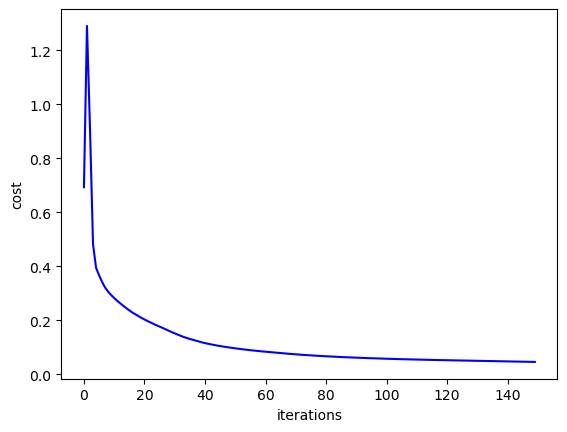

In [211]:
model.plot_cost()

### accurancy

In [214]:
model.estimate_true(X_test1, y_test1)

0.9909448818897638

In [215]:
y_predict1 = model.predict(X_test1)

In [216]:
y_predict1

array([1, 0, 0, ..., 1, 1, 0])

In [217]:
y_test1

1        1
1000     0
10001    0
10002    1
10011    1
        ..
9986     1
9989     1
9991     1
9996     1
9998     0
Name: 784, Length: 2540, dtype: int64